# Module 2 — From Sets to Graphs: **Message Passing, EdgeConv & ParticleNet**
### TIFR ML School 2026 · *Sets, Graphs & Symmetry for High-Energy Physics*

In **Module 1** a jet was a *set*: we embedded each particle on its own and pooled. That throws away
something physical — the **relations between particles**. Jet substructure (prongs, subjets, the angle
between two hard emissions) lives in how particles sit *relative to each other*. To use it we connect
particles with **edges** and let them exchange information: a **graph neural network**.

> **The one new ingredient: edges.** DeepSets pooled $\phi(x_i)$ over *independent* particles. A GNN first
> lets each particle build a message from its **neighbours**, *then* pools. The pooling — the
> permutation-invariant aggregation from Module 1 — is still the atom; we just feed it richer, relational
> inputs.

**What you will do, end-to-end:**
1. Write the **message-passing (MPNN)** recipe and see DeepSets as its edge-less special case.
2. Build a **k-NN graph** for a jet from scratch (pure torch — no `torch_cluster`).
3. Implement **EdgeConv** and **DynamicEdgeConv** from scratch on PyTorch-Geometric's `MessagePassing`.
4. Learn the **PyG data model** (ragged batching with `Data`/`Batch`, the `batch` vector, `global_mean_pool`).
5. Build and **train ParticleNet** for top-vs-QCD tagging; compare its ROC/AUC to Module 1's PFN.
6. **Visualize the dynamic graph** — watch connectivity move from η–φ space to learned feature space.
7. Meet **GravNet** (a learned-graph layer) as a concept + compact implementation.

**Dependencies:** `numpy torch torch_geometric matplotlib scikit-learn uproot awkward`.

## 1 · From a set to a graph

A graph is a set of **nodes** (here: particles) plus a set of **edges** (which particles are "neighbours").
Adding edges injects a **relational inductive bias**: we tell the network *which* particles should talk,
instead of forcing it to discover all pairwise structure through a global pool.

Two questions define a graph model:
- **Where do the edges come from?** In images the grid gives them for free; for a jet there is no grid, so we
  *construct* them — typically a **k-nearest-neighbour graph in the (η, φ) plane** (a particle talks to its
  $k$ angular neighbours). Other choices: radius graphs, fully-connected, or a graph **learned** by the network
  (GravNet, §7; and DynamicEdgeConv, which rebuilds the graph every layer).
- **What flows along an edge?** A *message* computed from the two endpoints, which is then aggregated and used
  to update each node. That is message passing.

## 2 · The Message-Passing recipe (MPNN)

One message-passing layer updates every node $i$ in three steps (Gilmer et al., 2017):

$$
\textbf{message: } \; m_{ij} = \psi\big(h_i,\, h_j\big)\ \ \text{for each neighbour } j\in\mathcal N(i)
\qquad
\textbf{aggregate: } \; a_i = \bigoplus_{j\in\mathcal N(i)} m_{ij}
\qquad
\textbf{update: } \; h_i' = \phi\big(h_i,\, a_i\big)
$$

The aggregator $\bigoplus$ (sum / mean / max) is **permutation-invariant over the neighbours** — it is exactly
the Deep Sets pool from Module 1, now applied to each *local* neighbourhood. So:

| model | edges $\mathcal N(i)$ | what you get |
|---|---|---|
| **DeepSets / PFN** | none ($m_i=\phi(x_i)$, one global pool) | Module 1 |
| **GNN / EdgeConv** | k-NN neighbours | **this module** |
| **Transformer** | *all* other nodes, softly weighted | Module 3 |

PyTorch-Geometric gives us the base class `MessagePassing`: we implement `message()` (the $\psi$) and pick an
`aggr` (the $\bigoplus$); it handles the bookkeeping of gathering neighbours and scattering results back.

In [1]:
%matplotlib inline
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

import torch_geometric
from torch_geometric.nn import MessagePassing, global_mean_pool
from torch_geometric.utils import scatter
from torch_geometric.data import Data
from torch_geometric.loader import DataLoader

torch.manual_seed(0); np.random.seed(0)
device = (torch.device("cuda") if torch.cuda.is_available()
          else torch.device("mps") if torch.backends.mps.is_available()
          else torch.device("cpu"))
print("torch", torch.__version__, "| PyG", torch_geometric.__version__, "| device", device)

torch 2.12.0 | PyG 2.7.0 | device mps


## 3 · Building a k-NN graph from scratch

We need edges. We compute them ourselves with pairwise distances + `topk` — no `torch_cluster` needed.
Two subtleties for HEP batches:
- A batch is **many jets at once** (PyG concatenates them into one big disconnected graph, see §5). The k-NN
  must stay **within each jet** — never connect particles from different jets. We enforce that with the
  per-node graph id `batch`.
- We exclude **self-loops** and handle tiny jets (fewer than $k+1$ particles) gracefully.

The convention we return is PyG's: `edge_index[0]` = source (neighbour $j$), `edge_index[1]` = target
(centre $i$); messages flow source→target and aggregate at the centre.

In [2]:
def knn_graph_native(x, k, batch):
    """Within-graph k-NN edge_index from node coordinates x (N, C). Pure torch (no torch_cluster).
    Returns edge_index [2, E] = [source(neighbour j), target(centre i)].
    O(N^2) memory in nodes-per-batch -> keep batch sizes moderate (torch_cluster/faiss scale to large N)."""
    with torch.no_grad():                                    # graph construction is non-differentiable
        N = x.size(0)
        x2 = (x * x).sum(dim=1, keepdim=True)                # (N,1)
        dist2 = x2 + x2.t() - 2.0 * (x @ x.t())              # (N,N) squared distances
        same = batch.unsqueeze(0) == batch.unsqueeze(1)      # (N,N) same-jet mask
        dist2 = dist2.masked_fill(~same, float("inf"))       # forbid cross-jet edges
        dist2.fill_diagonal_(float("inf"))                   # forbid self-loops
        kk = min(k, max(N - 1, 1))
        knn_d, idx = dist2.topk(kk, dim=1, largest=False)    # k nearest per centre (N, kk)
        valid = torch.isfinite(knn_d)                        # drop fillers for tiny jets
        centre = torch.arange(N, device=x.device).unsqueeze(1).expand(-1, kk)
        edge_index = torch.stack([idx[valid], centre[valid]], dim=0)
    return edge_index

# sanity: two tiny "jets" in one batch must never share an edge
xx = torch.tensor([[0.,0.],[0.1,0.],[0.,0.1],   [5.,5.],[5.1,5.],[5.,5.1]])
bb = torch.tensor([0,0,0, 1,1,1])
ei = knn_graph_native(xx, k=2, batch=bb)
cross = (bb[ei[0]] != bb[ei[1]]).sum().item()
print("edges:", ei.shape[1], "| cross-jet edges:", cross, "(must be 0)")

edges: 12 | cross-jet edges: 0 (must be 0)


## 4 · EdgeConv (the DGCNN layer)

EdgeConv (Wang et al., 2019) builds each message from the centre particle **and the displacement to its
neighbour**:
$$ m_{ij} = h_\Theta\big(\,x_i \,\Vert\, x_j - x_i\,\big), \qquad x_i' = \operatorname*{mean}_{j\in\mathcal N(i)} m_{ij}. $$
Concatenating $x_i$ (where I am) with $x_j-x_i$ (how my neighbour differs from me) lets the MLP $h_\Theta$ learn
local geometric structure — perfect for jet substructure. We implement it on `MessagePassing` by writing
`message()` and choosing `aggr="mean"`.

In [3]:
class EdgeConv(MessagePassing):
    """DGCNN EdgeConv:  x_i' = mean_j  MLP( [ x_i , x_j - x_i ] )."""
    def __init__(self, in_channels, out_channels, aggr="mean"):
        super().__init__(aggr=aggr)
        self.mlp = nn.Sequential(
            nn.Linear(2 * in_channels, out_channels), nn.BatchNorm1d(out_channels), nn.ReLU(),
            nn.Linear(out_channels, out_channels),    nn.BatchNorm1d(out_channels), nn.ReLU(),
        )
    def forward(self, x, edge_index):
        return self.propagate(edge_index, x=x)          # gathers neighbours, calls message(), aggregates
    def message(self, x_i, x_j):                         # x_i = centre, x_j = neighbour (per edge)
        return self.mlp(torch.cat([x_i, x_j - x_i], dim=-1))

# quick test on a 5-node toy graph
toy_x = torch.randn(5, 3)
toy_ei = torch.tensor([[1, 2, 0, 3, 4], [0, 0, 1, 2, 2]])     # edges j -> i
print("EdgeConv output shape:", EdgeConv(3, 8)(toy_x, toy_ei).shape, "(5 nodes -> 8 features)")

EdgeConv output shape: torch.Size([5, 8]) (5 nodes -> 8 features)


## 4b · DynamicEdgeConv and the EdgeConv block

**DynamicEdgeConv** rebuilds the k-NN graph from the *current* features at every layer — so after the first
layer particles are connected by *learned similarity*, not just angular proximity. We also define an
**EdgeConv block** with a residual shortcut (as in ParticleNet) for stable training.

In [4]:
class DynamicEdgeConv(EdgeConv):
    """EdgeConv that recomputes its own k-NN graph from the input features each call."""
    def __init__(self, in_channels, out_channels, k, aggr="mean"):
        super().__init__(in_channels, out_channels, aggr)
        self.k = k
    def forward(self, x, batch):
        edge_index = knn_graph_native(x, self.k, batch)
        return super().forward(x, edge_index)

class EdgeConvBlock(nn.Module):
    """ParticleNet-style block: EdgeConv on a given graph + linear residual shortcut, then ReLU."""
    def __init__(self, in_channels, out_channels, aggr="mean"):
        super().__init__()
        self.conv = EdgeConv(in_channels, out_channels, aggr)
        self.shortcut = nn.Linear(in_channels, out_channels)
        self.act = nn.ReLU()
    def forward(self, x, edge_index):
        return self.act(self.conv(x, edge_index) + self.shortcut(x))

## 5 · The PyG data model (ragged batching)

In Module 1 we padded every jet to a fixed length and carried a mask. Graphs use a cleaner idea: a batch of
jets is stored as **one big disconnected graph**.
- node features `x` of shape `(sum_of_all_particles, F)` — just concatenated, no padding;
- `edge_index` `(2, E)` indexing into those nodes;
- a `batch` vector `(N,)` telling which jet each node belongs to.

`global_mean_pool(x, batch)` then averages nodes **within each jet** to give one vector per jet — again the
Deep Sets pool, now as the graph-level readout. PyG's `Data` holds one jet; its `DataLoader` concatenates a
batch and builds `batch` for you. Let's turn JetClass jets into `Data` objects.

In [5]:
import os, uproot, awkward as ak

CANDIDATE_PATHS = [
    "../data/JetClass_example_100k.root",
    "/Users/sanmay/Documents/ML_SCHOOLS/MLSCHOOL_2023_ICTS/Main_School/JetDataset/JetClass_example_100k.root",
    "./JetClass_example_100k.root",
]
root_path = next((p for p in CANDIDATE_PATHS if os.path.exists(p)), None)
if root_path is None:
    raise FileNotFoundError("Place JetClass_example_100k.root in ../data/  "
                            "(https://hqu.web.cern.ch/datasets/JetClass/example/)")

MAX_PART  = 128
N_PER_CLS = 6000     # jets per class; raise for accuracy, lower for speed

tree = uproot.open(root_path)["tree"]
br = tree.arrays(["part_px","part_py","part_pz","part_energy","part_deta","part_dphi",
                  "label_QCD","label_Tbqq","label_Tbl"])
is_qcd = ak.to_numpy(br["label_QCD"]).astype(bool)
is_top = ak.to_numpy(br["label_Tbqq"]).astype(bool) | ak.to_numpy(br["label_Tbl"]).astype(bool)
sel = np.concatenate([np.where(is_qcd)[0][:N_PER_CLS], np.where(is_top)[0][:N_PER_CLS]])
labels = np.concatenate([np.zeros(N_PER_CLS), np.ones(N_PER_CLS)]).astype(np.int64)

px,py,pz,e = br["part_px"][sel], br["part_py"][sel], br["part_pz"][sel], br["part_energy"][sel]
deta,dphi  = br["part_deta"][sel], br["part_dphi"][sel]
pt = np.sqrt(px**2 + py**2); dR = np.sqrt(deta**2 + dphi**2)
sumpt, sume = ak.sum(pt, axis=1), ak.sum(e, axis=1)
feat_list = [deta, dphi, np.log(pt+1e-8), np.log(e+1e-8),
             np.log(pt/sumpt+1e-8), np.log(e/sume+1e-8), dR]
FEATURE_NAMES = ["deta","dphi","log_pt","log_e","log_pt_rel","log_e_rel","dR"]

def pad(f): return ak.to_numpy(ak.fill_none(ak.pad_none(f, MAX_PART, clip=True), 0.0))
X   = np.stack([pad(f) for f in feat_list], axis=-1).astype(np.float32)   # (Njet, MAX_PART, 7)
POS = np.stack([pad(deta), pad(dphi)], axis=-1).astype(np.float32)         # raw (eta,phi) for kNN + plots
nparts = np.minimum(ak.to_numpy(ak.num(pt, axis=1)), MAX_PART)
print("loaded", len(labels), "jets | X", X.shape, "| POS", POS.shape)

loaded 12000 jets | X (12000, 128, 7) | POS (12000, 128, 2)


In [6]:
# Standardize the 7 node features over all real particles (a mild simplification: uses full sample stats).
realmask = (np.arange(MAX_PART)[None, :] < nparts[:, None])
flat = X[realmask]
mean, std = flat.mean(0), flat.std(0) + 1e-6
Xs = (X - mean) / std

# Build one PyG Data per jet (ragged: only the real particles, no padding). pos stays raw (eta,phi).
data_list = []
for i in range(len(labels)):
    n = int(nparts[i])
    if n < 2:                                   # need at least one edge
        continue
    data_list.append(Data(x=torch.from_numpy(Xs[i, :n]),
                          pos=torch.from_numpy(POS[i, :n]),
                          y=torch.tensor([int(labels[i])], dtype=torch.long)))

import random
random.seed(0); random.shuffle(data_list)
n = len(data_list); a, b = int(0.70 * n), int(0.85 * n)
splits = {"train": data_list[:a], "val": data_list[a:b], "test": data_list[b:]}
loaders = {k: DataLoader(v, batch_size=32, shuffle=(k == "train")) for k, v in splits.items()}
print({k: len(v) for k, v in splits.items()})

# peek at one batch to see the ragged-batch layout
b0 = next(iter(loaders["train"]))
print("batched graph:", b0)
print("nodes:", b0.x.shape[0], "| graphs in batch:", b0.num_graphs, "| batch vector:", b0.batch[:8], "...")

{'train': 8400, 'val': 1800, 'test': 1800}
batched graph: DataBatch(x=[928, 7], y=[32], pos=[928, 2], batch=[928], ptr=[33])
nodes: 928 | graphs in batch: 32 | batch vector: tensor([0, 0, 0, 0, 0, 0, 0, 0]) ...


## 6 · ParticleNet

ParticleNet (Qu & Gouskos, 2020) is the HEP workhorse GNN. It stacks **EdgeConv blocks**, and crucially it is
**dynamic**: the first block builds its k-NN graph in the physical **(η, φ)** plane, but each subsequent block
rebuilds the graph in the **learned feature space** of the previous block. Particles that are far apart in the
detector but play a similar role in the jet end up connected. After the blocks, a global mean pool + MLP head
gives the class.

We record each block's `edge_index` so we can *see* this happen in §6c.

In [7]:
class ParticleNet(nn.Module):
    def __init__(self, in_feat, n_classes, k=8, conv_channels=(32, 64, 64), fc=128, dropout=0.1):
        super().__init__()
        self.k = k
        chans = [in_feat, *conv_channels]
        self.blocks = nn.ModuleList([EdgeConvBlock(chans[i], chans[i + 1])
                                     for i in range(len(conv_channels))])
        self.head = nn.Sequential(nn.Linear(conv_channels[-1], fc), nn.ReLU(),
                                  nn.Dropout(dropout), nn.Linear(fc, n_classes))
        self.last_edges = []

    def forward(self, data):
        batch = data.batch if getattr(data, "batch", None) is not None \
                else torch.zeros(data.x.size(0), dtype=torch.long, device=data.x.device)
        feats, coords = data.x, data.pos
        self.last_edges = []
        for b, block in enumerate(self.blocks):
            edge_index = knn_graph_native(coords, self.k, batch)   # block 0: eta-phi; later: feature space
            self.last_edges.append(edge_index)
            feats = block(feats, edge_index)
            coords = feats                                         # dynamic graph: next kNN uses learned feats
        return self.head(global_mean_pool(feats, batch))

model = ParticleNet(in_feat=len(FEATURE_NAMES), n_classes=2, k=8).to(device)
print(model)
print("forward check:", model(next(iter(loaders["train"])).to(device)).shape)

ParticleNet(
  (blocks): ModuleList(
    (0): EdgeConvBlock(
      (conv): EdgeConv()
      (shortcut): Linear(in_features=7, out_features=32, bias=True)
      (act): ReLU()
    )
    (1): EdgeConvBlock(
      (conv): EdgeConv()
      (shortcut): Linear(in_features=32, out_features=64, bias=True)
      (act): ReLU()
    )
    (2): EdgeConvBlock(
      (conv): EdgeConv()
      (shortcut): Linear(in_features=64, out_features=64, bias=True)
      (act): ReLU()
    )
  )
  (head): Sequential(
    (0): Linear(in_features=64, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.1, inplace=False)
    (3): Linear(in_features=128, out_features=2, bias=True)
  )
)


forward check: torch.Size([32, 2])


In [8]:
from sklearn.metrics import roc_auc_score, roc_curve

@torch.no_grad()
def evaluate(model, loader):
    model.eval(); ys, ps, loss_sum, ntot = [], [], 0.0, 0
    for data in loader:
        data = data.to(device)
        logits = model(data)
        loss_sum += F.cross_entropy(logits, data.y, reduction="sum").item(); ntot += data.num_graphs
        ys.append(data.y.cpu()); ps.append(F.softmax(logits, -1)[:, 1].cpu())
    y, p = torch.cat(ys).numpy(), torch.cat(ps).numpy()
    return {"loss": loss_sum / ntot, "acc": ((p > 0.5).astype(int) == y).mean(),
            "auc": roc_auc_score(y, p), "y": y, "p": p}

def background_rejection(y, p, eff=0.5):
    fpr, tpr, _ = roc_curve(y, p)
    return 1.0 / max(np.interp(eff, tpr, fpr), 1e-12)

def train_pnet(model, loaders, epochs=12, lr=1e-3):
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs)
    for ep in range(epochs):
        model.train()
        for data in loaders["train"]:
            data = data.to(device)
            loss = F.cross_entropy(model(data), data.y)
            opt.zero_grad(); loss.backward(); opt.step()
        sched.step()
        va = evaluate(model, loaders["val"])
        print(f"epoch {ep+1:2d}: val loss {va['loss']:.3f}  acc {va['acc']:.3f}  AUC {va['auc']:.4f}")
    return model

In [9]:
train_pnet(model, loaders, epochs=12)

epoch  1: val loss 0.162  acc 0.949  AUC 0.9866


epoch  2: val loss 0.124  acc 0.958  AUC 0.9901


epoch  3: val loss 0.127  acc 0.963  AUC 0.9892


epoch  4: val loss 0.110  acc 0.962  AUC 0.9922


epoch  5: val loss 0.125  acc 0.957  AUC 0.9914


...

epoch  9: val loss 0.104  acc 0.967  AUC 0.9919


epoch 10: val loss 0.104  acc 0.968  AUC 0.9917


epoch 11: val loss 0.108  acc 0.967  AUC 0.9915


epoch 12: val loss 0.105  acc 0.968  AUC 0.9915


ParticleNet(
  (blocks): ModuleList(
    (0): EdgeConvBlock(
      (conv): EdgeConv()
      (shortcut): Linear(in_features=7, out_features=32, bias=True)
      (act): ReLU()
    )
    (1): EdgeConvBlock(
      (conv): EdgeConv()
      (shortcut): Linear(in_features=32, out_features=64, bias=True)
      (act): ReLU()
    )
    (2): EdgeConvBlock(
      (conv): EdgeConv()
      (shortcut): Linear(in_features=64, out_features=64, bias=True)
      (act): ReLU()
    )
  )
  (head): Sequential(
    (0): Linear(in_features=64, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.1, inplace=False)
    (3): Linear(in_features=128, out_features=2, bias=True)
  )
)

ParticleNet test  AUC = 0.9921   acc = 0.9694
   background rejection 1/eps_B @ eps_S=0.3:     306.0
   background rejection 1/eps_B @ eps_S=0.5:     306.0
   background rejection 1/eps_B @ eps_S=0.7:     229.5
   (Module 1 PFN reference on the same task: AUC ~ 0.973)


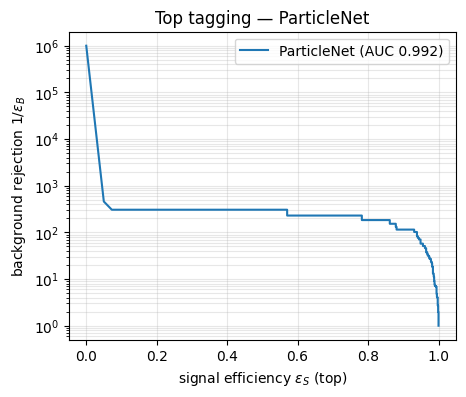

In [10]:
res = evaluate(model, loaders["test"])
print(f"ParticleNet test  AUC = {res['auc']:.4f}   acc = {res['acc']:.4f}")
for eff in (0.3, 0.5, 0.7):
    print(f"   background rejection 1/eps_B @ eps_S={eff}:  {background_rejection(res['y'], res['p'], eff):8.1f}")
print("   (Module 1 PFN reference on the same task: AUC ~ 0.973)")

fpr, tpr, _ = roc_curve(res["y"], res["p"])
plt.figure(figsize=(5, 4))
plt.plot(tpr, 1.0 / np.clip(fpr, 1e-6, 1), label=f"ParticleNet (AUC {res['auc']:.3f})")
plt.yscale("log"); plt.xlabel("signal efficiency $\\epsilon_S$ (top)")
plt.ylabel("background rejection $1/\\epsilon_B$")
plt.grid(True, which="both", alpha=0.3); plt.legend(); plt.title("Top tagging — ParticleNet"); plt.show()

## 6c · Watching the graph become dynamic

We run the trained model on a single jet and draw the k-NN graph used by each block, with particles placed at
their physical (Δη, Δφ). **Block 0** connects angular neighbours (short, local edges). **Later blocks** build
their graph in learned feature space, so edges can now jump across the jet to link particles the network finds
*functionally* similar. This is the "dynamic" in ParticleNet.

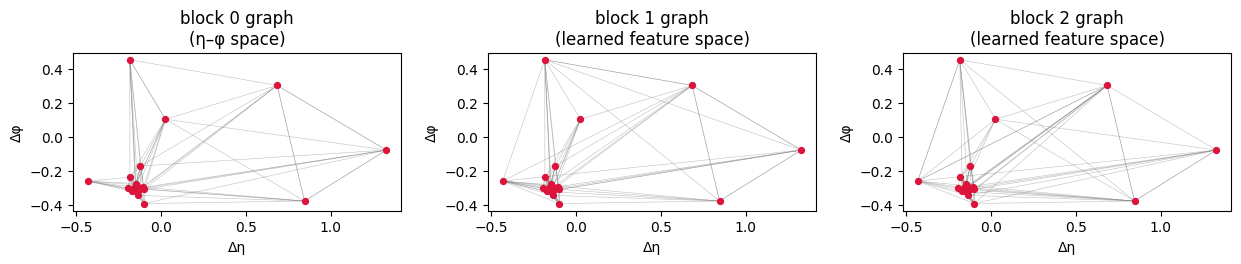

In [11]:
def plot_jet_graphs(model, jet):
    loader1 = DataLoader([jet], batch_size=1)
    data1 = next(iter(loader1)).to(device)
    model.eval()
    with torch.no_grad():
        model(data1)
    pos = jet.pos.numpy(); edges = [e.cpu().numpy() for e in model.last_edges]
    fig, axes = plt.subplots(1, len(edges), figsize=(4.2 * len(edges), 4.0))
    for b, (ax, ei) in enumerate(zip(axes, edges)):
        for s, d in zip(ei[0], ei[1]):
            ax.plot([pos[s, 0], pos[d, 0]], [pos[s, 1], pos[d, 1]], color="gray", lw=0.4, alpha=0.5)
        ax.scatter(pos[:, 0], pos[:, 1], s=18, c="crimson", zorder=3)
        ax.set_title(f"block {b} graph\n({'η–φ space' if b == 0 else 'learned feature space'})")
        ax.set_xlabel("Δη"); ax.set_ylabel("Δφ"); ax.set_aspect("equal")
    plt.tight_layout(); plt.show()

# pick a top jet with a reasonable number of particles
top_jet = next(j for j in splits["test"] if j.y.item() == 1 and j.x.shape[0] > 20)
plot_jet_graphs(model, top_jet)

## 7 · GravNet — learning the graph

ParticleNet *recomputes* k-NN from features; **GravNet** (Qasim et al., 2019) goes further and **learns a
low-dimensional "spatial" embedding** $S$ whose only job is to define neighbourhoods, plus a feature
embedding $f$ to propagate. Neighbours are found by k-NN **in $S$**, and each message is weighted by a
Gaussian of the learned distance $V(d_{ij}) = \exp(-d_{ij}^2)$:
$$ a_i = \big[\, \operatorname{mean}_{j} V(d_{ij})\,f_j \;\Vert\; \max_{j} V(d_{ij})\,f_j \,\big], \qquad
   h_i' = \sigma\big(W[\,x_i \Vert a_i\,]\big). $$
This is ideal for irregular calorimeter geometry, where there is no natural (η, φ) grid. Below is a compact
implementation; training it is left as an exercise. Note the neighbour *selection* is non-differentiable but
the distance *weights* are — so gradients still shape the learned space $S$.

In [12]:
class GravNetLayer(nn.Module):
    def __init__(self, in_channels, out_channels, space_dim=4, prop_dim=22, k=8):
        super().__init__()
        self.k = k
        self.lin_s = nn.Linear(in_channels, space_dim)             # learned coordinates S
        self.lin_f = nn.Linear(in_channels, prop_dim)              # features to propagate
        self.lin_out = nn.Sequential(nn.Linear(in_channels + 2 * prop_dim, out_channels), nn.ReLU())
    def forward(self, x, batch):
        s, f = self.lin_s(x), self.lin_f(x)
        j, i = knn_graph_native(s, self.k, batch)                  # neighbours in learned space S
        d2 = ((s[i] - s[j]) ** 2).sum(-1, keepdim=True)           # differentiable distances
        w = torch.exp(-d2)
        msg = f[j] * w
        a_mean = scatter(msg, i, dim=0, dim_size=x.size(0), reduce="mean")
        a_max  = scatter(msg, i, dim=0, dim_size=x.size(0), reduce="max")
        return self.lin_out(torch.cat([x, a_mean, a_max], dim=-1))

gb = next(iter(loaders["train"])).to(device)
print("GravNetLayer output:", GravNetLayer(len(FEATURE_NAMES), 32).to(device)(gb.x, gb.batch).shape)

GravNetLayer output: torch.Size([1052, 32])


## 8 · Exercises

1. **k matters.** Re-train ParticleNet with `k = 4, 8, 16`. How do AUC and background rejection scale with the
   neighbourhood size, and what does it cost in time?
2. **Static vs dynamic.** Disable the dynamic graph (use the η–φ graph in *every* block by setting
   `coords = data.pos` each iteration). How much does the dynamic graph actually buy?
3. **Aggregator.** Switch EdgeConv's `aggr` from `"mean"` to `"max"` (DGCNN's original choice) and to `"sum"`.
   Which wins for jets, and can you relate it to the Deep Sets discussion in Module 1?
4. **Edge features.** Add the edge length $\Delta R_{ij}$ as an explicit input to `message()`. Does telling the
   network the geometry help, or does EdgeConv already capture it via $x_j - x_i$?
5. **Train GravNet.** Stack 2–3 `GravNetLayer`s + global pool + head and train it. Compare to ParticleNet.
6. **PFN vs ParticleNet.** Overlay this ROC with Module 1's PFN ROC on the same test jets. Where on the curve
   do edges help most — high signal efficiency or high purity?

## 9 · Recap, and the bridge to Module 3

- A jet became a **graph**: particles (nodes) + k-NN **edges**. The new ingredient is the edge.
- **Message passing** = build a message per edge, **aggregate** over neighbours (the Deep Sets pool, locally),
  **update** the node. DeepSets is the edge-less special case.
- **EdgeConv** messages from $[x_i, x_j-x_i]$; **ParticleNet** stacks EdgeConv blocks and **rebuilds the graph
  in learned feature space** each block; **GravNet** learns the neighbourhood space itself.
- We batched ragged graphs the PyG way (`Data`/`Batch` + `batch` vector + `global_mean_pool`) and trained a
  top tagger, then *watched* the graph go from spatial to learned.

**What's next?** A k-NN graph is a *hard* choice of neighbours: each particle talks to exactly $k$ others, all
equally. But maybe every particle should talk to *every* other, with a **learned, soft weight**. That is
**attention** — a fully-connected graph whose edge weights are computed on the fly — and it gives the
**Particle Transformer**. On to **Module 3**.